# EDA – Bank Marketing

Este notebook realiza un EDA sobre los datasets entregados.

In [29]:
from pathlib import Path

# Ir un nivel arriba desde notebooks hasta la raíz del proyecto
BASE = Path.cwd().resolve().parents[0]
RAW = BASE / "data" / "raw"
PROC = BASE / "data" / "processed"



In [30]:
# 2) Lectura de datos crudos
bank_path = RAW / "bank-additional.csv"
cust_path = RAW / "customer-details.xlsx"

df_bank = pd.read_csv(bank_path)
xls = pd.ExcelFile(cust_path)
df_cust = pd.concat([pd.read_excel(xls, s).assign(sheet=s) for s in xls.sheet_names], ignore_index=True)

df_bank.head(), df_cust.head()




(   Unnamed: 0   age        job  marital    education  default  housing  loan  \
 0           0   NaN  housemaid  MARRIED     basic.4y      0.0      0.0   0.0   
 1           1  57.0   services  MARRIED  high.school      NaN      0.0   0.0   
 2           2  37.0   services  MARRIED  high.school      0.0      1.0   0.0   
 3           3  40.0     admin.  MARRIED     basic.6y      0.0      0.0   0.0   
 4           4  56.0   services  MARRIED  high.school      0.0      0.0   1.0   
 
      contact  duration  ...  emp.var.rate  cons.price.idx  cons.conf.idx  \
 0  telephone       261  ...           1.1          93,994          -36,4   
 1  telephone       149  ...           1.1          93,994          -36,4   
 2  telephone       226  ...           1.1          93,994          -36,4   
 3  telephone       151  ...           1.1          93,994          -36,4   
 4  telephone       307  ...           1.1          93,994          -36,4   
 
   euribor3m  nr.employed   y                dat

In [31]:
# 3) Información general
display(df_bank.shape)
display(df_bank.info())
display(df_bank.describe(include='all'))

display(df_cust.shape)
display(df_cust.info())
display(df_cust.describe(include='all'))


(43000, 24)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  object 
 3   marital         42915 non-null  object 
 4   education       41193 non-null  object 
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  object 
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  object 
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  object 
 16  cons.conf.idx   43000 non-null  object 
 17  euribor3m       33744 non-null 

None

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
count,43000.000000,37880.000000,42655,42915,41193,34019.000000,41974.000000,41974.000000,43000,43000.000000,...,43000.000000,42529,43000,33744,43000,43000,42752,43000.000000,43000.000000,43000
unique,NaN,NaN,11,3,7,NaN,NaN,NaN,2,NaN,...,NaN,26,26,309,11,2,1825,NaN,NaN,43000
top,NaN,NaN,admin.,MARRIED,university.degree,NaN,NaN,NaN,cellular,NaN,...,NaN,"93,994","-36,4","4,857","5228,1",no,28-febrero-2018,NaN,NaN,089b39d8-e4d0-461b-87d4-814d71e0e079
freq,NaN,NaN,10873,25999,12722,NaN,NaN,NaN,27396,NaN,...,NaN,7938,8020,2287,16980,38156,95,NaN,NaN,1
mean,20651.099047,39.977112,NaN,NaN,NaN,0.000088,0.535998,0.155620,NaN,257.739279,...,0.077128,NaN,NaN,NaN,NaN,NaN,NaN,36.856697,-95.939067,NaN
std,11868.770913,10.437957,NaN,NaN,NaN,0.009390,0.498708,0.362499,NaN,258.666033,...,1.573898,NaN,NaN,NaN,NaN,NaN,NaN,7.225948,16.752282,NaN
min,0.000000,17.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,0.000000,...,-3.400000,NaN,NaN,NaN,NaN,NaN,NaN,24.396000,-124.997000,NaN
25%,10381.750000,32.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,102.000000,...,-1.800000,NaN,NaN,NaN,NaN,NaN,NaN,30.614750,-110.494250,NaN
50%,20642.500000,38.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,179.000000,...,1.100000,NaN,NaN,NaN,NaN,NaN,NaN,36.761000,-95.899500,NaN
75%,30930.250000,47.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,319.000000,...,1.400000,NaN,NaN,NaN,NaN,NaN,NaN,43.113250,-81.427750,NaN


(43170, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[ns]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  object        
 7   sheet              43170 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(2)
memory usage: 2.6+ MB


None

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,sheet
count,43170.000000,43170.000000,43170.000000,43170.000000,43170,43170.000000,43170,43170
unique,NaN,NaN,NaN,NaN,NaN,NaN,43170,3
top,NaN,NaN,NaN,NaN,NaN,NaN,089b39d8-e4d0-461b-87d4-814d71e0e079,2012
freq,NaN,NaN,NaN,NaN,NaN,NaN,1,20115
mean,7916.022469,93227.389622,1.004749,0.998633,2013-05-11 22:09:47.407922176,16.591290,NaN,NaN
min,0.000000,5841.000000,0.000000,0.000000,2012-01-01 00:00:00,1.000000,NaN,NaN
25%,3597.000000,49608.000000,0.000000,0.000000,2012-07-16 00:00:00,9.000000,NaN,NaN
50%,7194.500000,93009.500000,1.000000,1.000000,2013-03-01 00:00:00,17.000000,NaN,NaN
75%,11705.750000,136740.500000,2.000000,2.000000,2014-03-28 00:00:00,25.000000,NaN,NaN
max,20114.000000,180802.000000,2.000000,2.000000,2014-12-31 00:00:00,32.000000,NaN,NaN


In [32]:
# 4) Limpieza rápida
df_bank = df_bank.drop_duplicates().copy()
df_cust = df_cust.drop_duplicates().copy()

# Tipificación de fechas si existen
for col in ["date", "Dt_Customer"]:
    if col in df_bank.columns:
        df_bank[col] = pd.to_datetime(df_bank[col], errors='coerce', dayfirst=True)
    if col in df_cust.columns:
        df_cust[col] = pd.to_datetime(df_cust[col], errors='coerce', dayfirst=True)

df_bank.isna().mean().sort_values(ascending=False).head(10), df_cust.isna().mean().sort_values(ascending=False).head(10)

/var/folders/db/fwv1r_095jb9mrrg1vk739s00000gn/T/ipykernel_68813/787645575.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_bank[col] = pd.to_datetime(df_bank[col], errors='coerce', dayfirst=True)


(date              1.000000
 euribor3m         0.215256
 default           0.208860
 age               0.119070
 education         0.042023
 housing           0.023860
 loan              0.023860
 cons.price.idx    0.010953
 job               0.008023
 marital           0.001977
 dtype: float64,
 Unnamed: 0           0.0
 Income               0.0
 Kidhome              0.0
 Teenhome             0.0
 Dt_Customer          0.0
 NumWebVisitsMonth    0.0
 ID                   0.0
 sheet                0.0
 dtype: float64)

In [33]:
# 5) Unión (si hay identificadores compatibles)
df_merged = None
if "id_" in df_bank.columns and "ID" in df_cust.columns:
    df_merged = df_bank.merge(df_cust, left_on="id_", right_on="ID", how="left", suffixes=("", "_cust"))
else:
    df_merged = df_bank.copy()

df_merged.shape, df_merged.head()

((43000, 32),
    Unnamed: 0   age        job  marital    education  default  housing  loan  \
 0           0   NaN  housemaid  MARRIED     basic.4y      0.0      0.0   0.0   
 1           1  57.0   services  MARRIED  high.school      NaN      0.0   0.0   
 2           2  37.0   services  MARRIED  high.school      0.0      1.0   0.0   
 3           3  40.0     admin.  MARRIED     basic.6y      0.0      0.0   0.0   
 4           4  56.0   services  MARRIED  high.school      0.0      0.0   1.0   
 
      contact  duration  ...  longitude                                   id_  \
 0  telephone       261  ...    -71.233  089b39d8-e4d0-461b-87d4-814d71e0e079   
 1  telephone       149  ...    -83.923  e9d37224-cb6f-4942-98d7-46672963d097   
 2  telephone       226  ...    -94.847  3f9f49b5-e410-4948-bf6e-f9244f04918b   
 3  telephone       151  ...    -70.308  9991fafb-4447-451a-8be2-b0df6098d13e   
 4  telephone       307  ...   -104.463  eca60b76-70b6-4077-80ba-bc52e8ebb0eb   
 
    Unname

Numéricas: ['Unnamed: 0', 'age', 'default', 'housing', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate']
Categóricas: ['job', 'marital', 'education', 'contact', 'poutcome', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


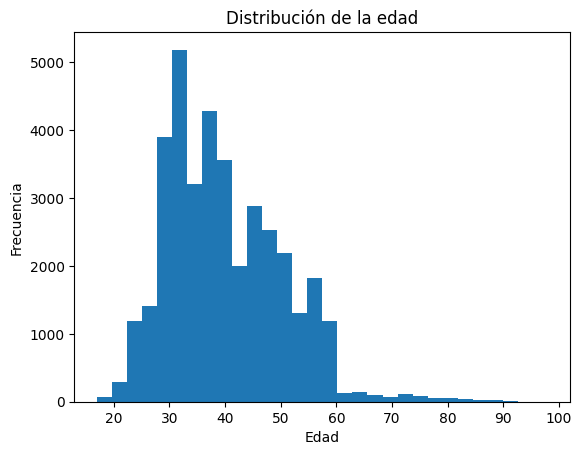

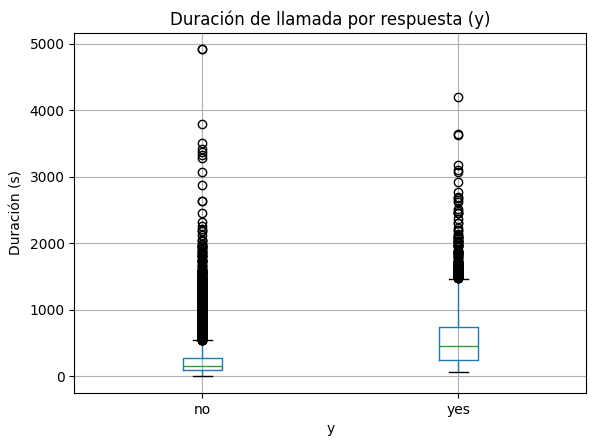

In [34]:
# 6) Análisis univariante (ejemplos)
num_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_merged.select_dtypes(exclude=[np.number, 'datetime']).columns.tolist()

print("Numéricas:", num_cols[:10])
print("Categóricas:", cat_cols[:10])

# Histograma de edad si existe
if 'age' in df_merged.columns:
    df_merged['age'].plot(kind='hist', bins=30, title='Distribución de la edad')
    plt.xlabel('Edad')
    plt.ylabel('Frecuencia')
    plt.show()

# Boxplot de duración por respuesta si existen
if 'duration' in df_merged.columns and 'y' in df_merged.columns:
    # Convertir y a string para plot
    df_merged['y_str'] = df_merged['y'].astype(str)
    df_merged.boxplot(column='duration', by='y_str')
    plt.title('Duración de llamada por respuesta (y)')
    plt.suptitle('')
    plt.xlabel('y')
    plt.ylabel('Duración (s)')
    plt.show()

In [ ]:
# 7) Análisis bivariante (ejemplo)
# Tasa de conversión por 'job' si existen
if 'job' in df_merged.columns and 'y' in df_merged.columns:
    # Convertimos la columna 'y' a binaria 1/0 directamente en el dataframe
    df_merged['y_num'] = df_merged['y'].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})

    conv_by_job = df_merged.groupby('job')['y_num'].mean().sort_values(ascending=False)

    display(conv_by_job.head(10))
    conv_by_job.plot(kind='bar', title='Tasa de suscripción por profesión (job)')
    plt.ylabel('Tasa')
    plt.show()




KeyError: 'Columns not found: 0, 1'

## 8) Insights y conclusiones

- **Variables relevantes:** …
- **Patrones de conversión:** …
- **Recomendaciones para marketing:** …